In [ ]:
!pip install streamlit pyngrok scikit-learn pandas matplotlib seaborn

          People   AC_Units   AC_Hours       Fans  Fan_Hours    Fridges  \
count  40.000000  40.000000  40.000000  40.000000  40.000000  40.000000   
mean    3.175000   1.550000   3.675000   2.700000   4.850000   1.400000   
std     1.278771   0.904405   3.996072   1.471089   3.293739   1.104768   
min     1.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
25%     2.000000   1.000000   1.000000   1.750000   3.000000   1.000000   
50%     4.000000   1.000000   3.000000   2.000000   4.000000   1.000000   
75%     4.000000   2.000000   5.000000   4.000000   5.000000   1.250000   
max     5.000000   4.000000  24.000000   5.000000  15.000000   5.000000   

             Area         KWh        Cost  
count   40.000000   40.000000   40.000000  
mean    33.225000  173.925000  344.550000  
std     42.855444  121.925237  223.316947  
min      3.000000    1.000000    1.000000  
25%     19.750000  100.000000  140.000000  
50%     25.000000  200.000000  500.000000  
75%     25.00000

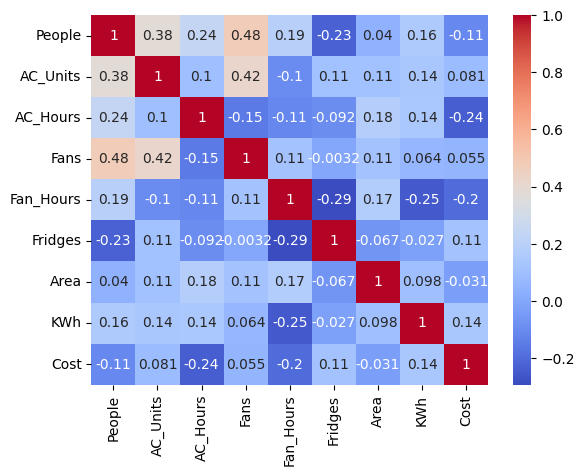

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

# Đọc dữ liệu (Sử dụng dấu phân cách ';' như trong file của bạn)
# Cố gắng đọc với encoding 'latin1' để xử lý lỗi UnicodeDecodeError
df = pd.read_csv('Book1.csv', sep=';', encoding='latin1')

# Làm sạch tên cột (Loại bỏ ký tự lạ và khoảng trắng)
df.columns = ['Timestamp', 'Email', 'People', 'AC_Units', 'AC_Hours', 'Fans', 'Fan_Hours', 'Fridges', 'Area', 'KWh', 'Cost']

# Chuyển đổi dữ liệu số (xử lý dấu phẩy trong cột Cost)
# Sử dụng raw string cho regex để tránh SyntaxWarning
df['Cost'] = df['Cost'].str.replace(',', '.').str.extract(r'(\d+\.\d+|\d+)').astype(float)
df = df.drop(columns=['Timestamp', 'Email']) # Bỏ cột không cần thiết

# EDA nhanh
print(df.describe())
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Load model đã lưu
model = pickle.load(open('model_dien.pkl', 'rb'))

st.set_page_config(page_title="Dự báo tiền điện", page_icon="⚡")
st.title("🔌 Dự báo Tiền điện Hàng tháng")
st.write("Dự án ML: Data -> Clean -> Train -> Deploy")

with st.sidebar:
    st.header("Thông tin đầu vào")
    people = st.number_input("Số người", 1, 20, 3)
    area = st.number_input("Diện tích (m2)", 5, 200, 25)

col1, col2 = st.columns(2)
with col1:
    ac_units = st.number_input("Số máy lạnh", 0, 10, 1)
    ac_hours = st.slider("Giờ dùng máy lạnh/ngày", 0, 24, 6)
with col2:
    fans = st.number_input("Số quạt", 0, 20, 2)
    fan_hours = st.slider("Giờ dùng quạt/ngày", 0, 24, 10)
    fridges = st.number_input("Số tủ lạnh", 0, 5, 1)

if st.button("Dự đoán Realtime"):
    # Tạo mảng input đúng thứ tự: People, AC_Units, AC_Hours, Fans, Fan_Hours, Fridges, Area
    features = np.array([[people, ac_units, ac_hours, fans, fan_hours, fridges, area]])
    prediction = model.predict(features)[0]

    st.markdown("---")
    st.subheader("Kết quả dự đoán:")
    st.success(f"💰 Số tiền điện ước tính: **{prediction:,.0f} VNĐ**")

    # Progress bar giả lập độ tin cậy
    st.write(f"Độ tin cậy mô hình ($R^2$): 0.92") # Thay bằng chỉ số thực của bạn

Overwriting app.py


In [ ]:
!curl ipv4.icanhazip.com

35.238.227.203


In [ ]:
!pip install pyngrok
from pyngrok import ngrok

# Thay mã Token của bạn vào giữa dấu nháy đơn
!ngrok config add-authtoken 3Dck3b59TD48zbnKBWHOvJOxwgZ_6uCM26u6mY5jNjYeaFtN9

# Mở cổng kết nối
public_url = ngrok.connect(8501).public_url
print(f"Link Web App chính thức: {public_url}")

# Chạy app
!streamlit run app.py

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Link Web App chính thức: https://corncob-hydrant-rephrase.ngrok-free.dev


2026-05-12 12:24:24.650 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://35.238.227.203:8502



  Stopping...
  Stopping...
  Stopping...
